# Tutorial 8: PV and probabilistic forecasting

This tutorial extends the day-ahead forecasting workflow from Tutorial 7. We first use the GEFCom2012 aggregate load to study forecast uncertainty, because the data and point-forecast specification are already familiar. We then prepare the structure for a later PV exercise without inventing a dataset.

The main distinction is between:

- a **point forecast**, which provides one value at each forecast horizon;
- a **prediction interval**, which provides marginal lower and upper bounds; and
- a **scenario forecast**, which provides complete trajectories and preserves relationships between hours.

## Learning outcomes

By the end of the tutorial, you should be able to:

1. separate training, calibration and test periods chronologically;
2. construct constant and hour-dependent residual prediction intervals;
3. fit linear quantile-regression models;
4. assess coverage, sharpness, quantile score and interval score;
5. generate independent and temporally correlated Gaussian scenarios; and
6. explain how physical constraints affect PV point and probabilistic forecasts.

## Indicative schedule

- set-up, point forecast and residual diagnosis: 15 minutes;
- residual-based intervals: 25 minutes;
- quantile regression and interval evaluation: 25 minutes;
- Gaussian trajectory scenarios: 25 minutes;
- PV design discussion: 10 minutes.

## 1. Set-up and GEFCom2012 data

We reuse the aggregate `Z21` load and mean temperature extract from Tutorial 7. The source is GEFCom2012, documented in `data/tutorial_07/README.md`.

The forecast is issued at the end of each day for all 24 hours of the next day. The code evaluates many such day-ahead forecasts together in chronological tables. Every predictor must have been available at the corresponding forecast origin.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import QuantileRegressor, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

DATA_PATH = Path("data") / "tutorial_07" / "gefcom2012_system_load.csv"

system_data = pd.read_csv(
    DATA_PATH,
    index_col="timestamp",
    parse_dates=True,
).sort_index()

expected_index = pd.date_range(
    system_data.index.min(), system_data.index.max(), freq="h"
)

print("Rows:", len(system_data))
print("Period:", system_data.index.min(), "to", system_data.index.max())
print("Duplicate timestamps:", system_data.index.duplicated().sum())
print("Missing timestamps:", len(expected_index.difference(system_data.index)))
print("Missing values by column:")
display(system_data.isna().sum().to_frame("Count"))

Rows: 8760
Period: 2007-01-01 00:00:00 to 2007-12-31 23:00:00
Duplicate timestamps: 0
Missing timestamps: 0
Missing values by column:


,Count
load_mw,0
air_temperature_c,0


## 2. Point forecast and chronological split

We use the same transparent predictors as Tutorial 7:

- load from the same hour on the previous day and previous week;
- temperature from the same hour on the previous day, used as a simple weather-forecast proxy; and
- calendar variables known at the forecast origin.

The split follows the lecture terminology:

- **training:** fit the point and quantile models;
- **calibration:** estimate residual uncertainty; and
- **test:** evaluate every method once.

The calibration set must not be used to report final performance. The test set must not influence model fitting, interval construction or parameter selection.

In [2]:
def make_features(data):
    features = pd.DataFrame(index=data.index)
    features["target"] = data["load_mw"]
    features["load_lag_24"] = data["load_mw"].shift(24)
    features["load_lag_168"] = data["load_mw"].shift(168)
    features["temperature_lag_24"] = data["air_temperature_c"].shift(24)

    hour = features.index.hour
    day_of_week = features.index.dayofweek
    features["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    features["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    features["day_sin"] = np.sin(2 * np.pi * day_of_week / 7)
    features["day_cos"] = np.cos(2 * np.pi * day_of_week / 7)
    features["is_weekend"] = (day_of_week >= 5).astype(int)
    return features.dropna()


FEATURE_COLUMNS = [
    "load_lag_24",
    "load_lag_168",
    "temperature_lag_24",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "is_weekend",
]

features = make_features(system_data)

TRAIN_START = pd.Timestamp("2007-01-08 00:00")
TRAIN_END = pd.Timestamp("2007-06-30 23:00")
CALIBRATION_START = pd.Timestamp("2007-07-01 00:00")
CALIBRATION_END = pd.Timestamp("2007-07-31 23:00")
TEST_START = pd.Timestamp("2007-08-01 00:00")
TEST_END = pd.Timestamp("2007-08-28 23:00")

train = features.loc[TRAIN_START:TRAIN_END]
calibration = features.loc[CALIBRATION_START:CALIBRATION_END]
test = features.loc[TEST_START:TEST_END]

assert len(calibration) == 31 * 24
assert len(test) == 28 * 24
assert not train.isna().any().any()
assert not calibration.isna().any().any()
assert not test.isna().any().any()

pd.DataFrame({
    "Start": [train.index.min(), calibration.index.min(), test.index.min()],
    "End": [train.index.max(), calibration.index.max(), test.index.max()],
    "Hours": [len(train), len(calibration), len(test)],
}, index=["Training", "Calibration", "Test"])

,Start,End,Hours
Training,2007-01-08,2007-06-30 23:00:00,4176
Calibration,2007-07-01,2007-07-31 23:00:00,744
Test,2007-08-01,2007-08-28 23:00:00,672


### 2.1 Worked point-forecast baseline

The pooled Ridge model is supplied so that tutorial time can focus on uncertainty. The calibration residual is

\[
e_t = y_t - \hat{y}_t.
\]

A positive residual means the point forecast was too low. The residual plot by hour motivates interval widths that can change through the day.

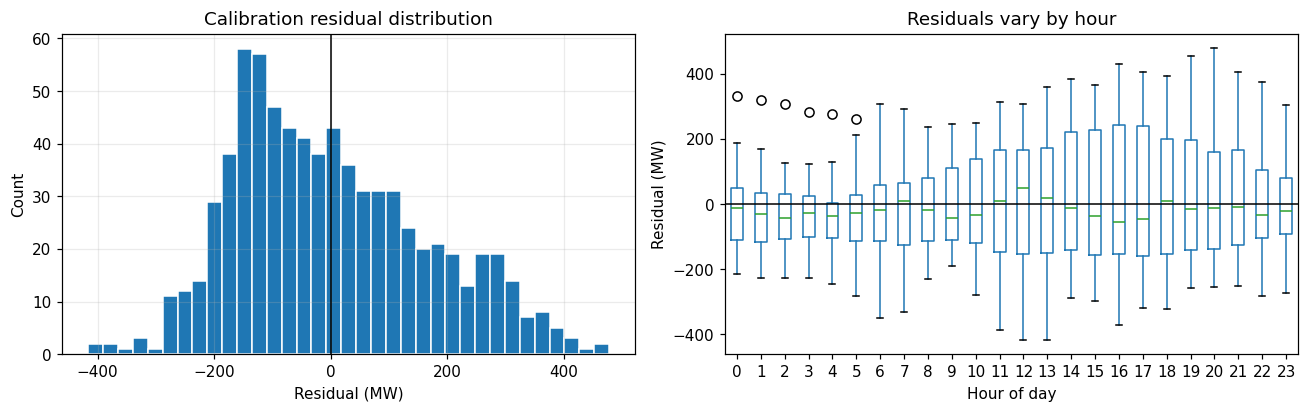

In [3]:
point_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=10.0),
)
point_model.fit(train[FEATURE_COLUMNS], train["target"])

calibration_point = pd.Series(
    point_model.predict(calibration[FEATURE_COLUMNS]),
    index=calibration.index,
    name="Point forecast",
)
test_point = pd.Series(
    point_model.predict(test[FEATURE_COLUMNS]),
    index=test.index,
    name="Point forecast",
)

calibration_residuals = calibration["target"] - calibration_point

residual_frame = pd.DataFrame({
    "Residual (MW)": calibration_residuals,
    "Hour of day": calibration_residuals.index.hour,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(calibration_residuals, bins=35, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set(title="Calibration residual distribution", xlabel="Residual (MW)", ylabel="Count")

residual_frame.boxplot(
    column="Residual (MW)", by="Hour of day", ax=axes[1], grid=False
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(title="Residuals vary by hour", xlabel="Hour of day", ylabel="Residual (MW)")
fig.suptitle("")
plt.tight_layout()
plt.show()

## 3. Task 1 — Residual-based prediction intervals

For a central 90% interval, set \(\alpha=0.10\) and estimate the 5th and 95th percentiles of calibration residuals.

The first method pools all calibration residuals. It adds the same two residual quantiles to every point forecast, so its width remains constant throughout the day.

The second method estimates separate residual quantiles for each hour of day. It can represent systematic changes in uncertainty between, for example, the morning ramp and the overnight period. Each hourly estimate uses fewer calibration observations, so the estimates can also be noisier.

In [4]:
def constant_residual_interval(point_forecast, residuals, alpha=0.10):
    lower_offset, upper_offset = np.quantile(
        residuals.to_numpy(), [alpha / 2, 1 - alpha / 2]
    )
    lower = point_forecast + lower_offset
    upper = point_forecast + upper_offset
    return lower.rename("Lower"), upper.rename("Upper")


def hourly_residual_interval(point_forecast, residuals, alpha=0.10):
    calibration_frame = pd.DataFrame({
        "residual": residuals,
        "hour": residuals.index.hour,
    })
    hourly_quantiles = calibration_frame.groupby("hour")["residual"].quantile(
        [alpha / 2, 1 - alpha / 2]
    ).unstack()

    forecast_hours = point_forecast.index.hour
    lower_offsets = hourly_quantiles.loc[forecast_hours, alpha / 2].to_numpy()
    upper_offsets = hourly_quantiles.loc[forecast_hours, 1 - alpha / 2].to_numpy()

    lower = pd.Series(
        point_forecast.to_numpy() + lower_offsets,
        index=point_forecast.index,
        name="Lower",
    )
    upper = pd.Series(
        point_forecast.to_numpy() + upper_offsets,
        index=point_forecast.index,
        name="Upper",
    )
    return lower, upper


NOMINAL_COVERAGE = 0.90
ALPHA = 1 - NOMINAL_COVERAGE

constant_lower, constant_upper = constant_residual_interval(
    test_point, calibration_residuals, alpha=ALPHA
)
hourly_lower, hourly_upper = hourly_residual_interval(
    test_point, calibration_residuals, alpha=ALPHA
)

intervals = {
    "Constant residual": (constant_lower, constant_upper),
    "Hourly residual": (hourly_lower, hourly_upper),
}

## 4. Task 2 — Interval and quantile metrics

For observations \(y_t\), lower bounds \(L_t\) and upper bounds \(U_t\):

\[
\text{Coverage} = \frac{100}{n}\sum_t \mathbb{1}\{L_t \le y_t \le U_t\},
\qquad
\text{Mean width} = \frac{1}{n}\sum_t (U_t-L_t).
\]

Coverage measures calibration and width measures sharpness. Widths should only be compared for the same nominal coverage.

The quantile score at level \(q\) is the mean pinball loss:

\[
QS_q = \frac{1}{n}\sum_t \max\{q(y_t-\hat{y}_{q,t}),\;(q-1)(y_t-\hat{y}_{q,t})\}.
\]

The interval score combines width with penalties for observations outside a central interval. Lower values are better for both quantile and interval scores.

In [5]:
def _equal_arrays(*values):
    arrays = [np.asarray(value, dtype=float) for value in values]
    lengths = {len(array) for array in arrays}
    if len(lengths) != 1:
        raise ValueError("All inputs must have identical lengths.")
    if any(not np.isfinite(array).all() for array in arrays):
        raise ValueError("Inputs must contain only finite values.")
    return arrays


def empirical_coverage(actual, lower, upper):
    actual_array, lower_array, upper_array = _equal_arrays(actual, lower, upper)
    if np.any(lower_array > upper_array):
        raise ValueError("Lower bounds must not exceed upper bounds.")
    covered = (actual_array >= lower_array) & (actual_array <= upper_array)
    return 100 * covered.mean()


def mean_interval_width(lower, upper):
    lower_array, upper_array = _equal_arrays(lower, upper)
    if np.any(lower_array > upper_array):
        raise ValueError("Lower bounds must not exceed upper bounds.")
    return np.mean(upper_array - lower_array)


def quantile_score(actual, quantile_forecast, quantile):
    if not 0 < quantile < 1:
        raise ValueError("quantile must lie strictly between zero and one.")
    actual_array, forecast_array = _equal_arrays(actual, quantile_forecast)
    error = actual_array - forecast_array
    return np.mean(np.maximum(quantile * error, (quantile - 1) * error))


def interval_score(actual, lower, upper, alpha=0.10):
    if not 0 < alpha < 1:
        raise ValueError("alpha must lie strictly between zero and one.")
    actual_array, lower_array, upper_array = _equal_arrays(actual, lower, upper)
    if np.any(lower_array > upper_array):
        raise ValueError("Lower bounds must not exceed upper bounds.")

    score = upper_array - lower_array
    score += (2 / alpha) * (lower_array - actual_array) * (actual_array < lower_array)
    score += (2 / alpha) * (actual_array - upper_array) * (actual_array > upper_array)
    return np.mean(score)

In [6]:
def summarise_intervals(actual, interval_dictionary, alpha=0.10):
    rows = {}
    for method_name, (lower, upper) in interval_dictionary.items():
        rows[method_name] = {
            "Coverage (%)": empirical_coverage(actual, lower, upper),
            "Mean width (MW)": mean_interval_width(lower, upper),
            "Interval score": interval_score(actual, lower, upper, alpha),
        }
    return pd.DataFrame(rows).T


residual_interval_summary = summarise_intervals(
    test["target"], intervals, alpha=ALPHA
)
residual_interval_summary.round(2)

,Coverage (%),Mean width (MW),Interval score
Constant residual,80.21,529.52,1010.70
Hourly residual,74.55,460.98,1015.53


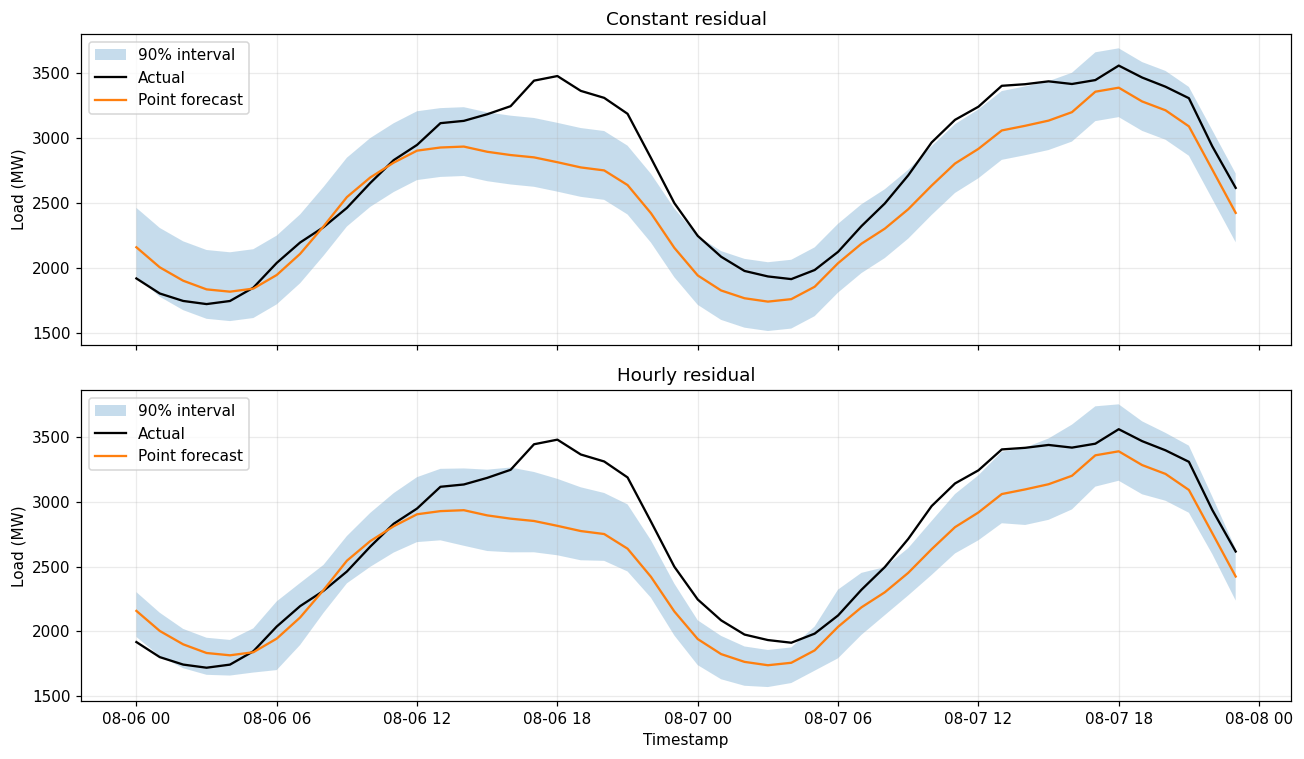

In [7]:
plot_index = test.loc["2007-08-06":"2007-08-07"].index

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, (method_name, (lower, upper)) in zip(axes, intervals.items()):
    ax.fill_between(
        plot_index,
        lower.loc[plot_index].to_numpy(),
        upper.loc[plot_index].to_numpy(),
        alpha=0.25,
        label="90% interval",
    )
    ax.plot(plot_index, test.loc[plot_index, "target"], color="black", label="Actual")
    ax.plot(plot_index, test_point.loc[plot_index], color="tab:orange", label="Point forecast")
    ax.set(title=method_name, ylabel="Load (MW)")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

## 5. Task 3 — Linear quantile regression

Residual intervals shift one point forecast using errors observed on the calibration set. Quantile regression instead estimates a conditional quantile directly. We fit separate linear models for \(q=0.05\), \(0.50\) and \(0.95\) using pinball loss.

The models use the training period only. The calibration period remains reserved for the residual methods, which keeps the comparison transparent. Separately fitted quantiles can cross; the code counts crossings and sorts the three forecasts at each timestamp before using them as an interval.

In [8]:
QUANTILES = [0.05, 0.50, 0.95]
quantile_models = {}
raw_quantile_predictions = pd.DataFrame(index=test.index)

for quantile in QUANTILES:
    model = make_pipeline(
        StandardScaler(),
        QuantileRegressor(quantile=quantile, alpha=0.01, solver="highs"),
    )
    model.fit(train[FEATURE_COLUMNS], train["target"])
    quantile_models[quantile] = model
    raw_quantile_predictions[quantile] = model.predict(test[FEATURE_COLUMNS])

crossing_mask = (
    (raw_quantile_predictions[0.05] > raw_quantile_predictions[0.50])
    | (raw_quantile_predictions[0.50] > raw_quantile_predictions[0.95])
)
print("Timestamps with crossing quantiles:", crossing_mask.sum())

ordered_predictions = np.sort(raw_quantile_predictions.to_numpy(), axis=1)
quantile_predictions = pd.DataFrame(
    ordered_predictions,
    index=test.index,
    columns=QUANTILES,
)

intervals["Linear quantile regression"] = (
    quantile_predictions[0.05].rename("Lower"),
    quantile_predictions[0.95].rename("Upper"),
)

Timestamps with crossing quantiles: 0


In [9]:
interval_summary = summarise_intervals(test["target"], intervals, alpha=ALPHA)

tail_quantile_scores = pd.DataFrame({
    method_name: {
        "QS q=0.05": quantile_score(test["target"], lower, 0.05),
        "QS q=0.95": quantile_score(test["target"], upper, 0.95),
    }
    for method_name, (lower, upper) in intervals.items()
}).T
tail_quantile_scores["Sum of tail QS"] = tail_quantile_scores.sum(axis=1)

print("Interval metrics")
display(interval_summary.round(2))
print("Quantile scores for the interval bounds")
display(tail_quantile_scores.round(2))
print(
    "Median quantile score:",
    round(quantile_score(test["target"], quantile_predictions[0.50], 0.50), 2),
)

Interval metrics


,Coverage (%),Mean width (MW),Interval score
Constant residual,80.21,529.52,1010.70
Hourly residual,74.55,460.98,1015.53
Linear quantile regression,94.64,804.67,908.38


Quantile scores for the interval bounds


,QS q=0.05,QS q=0.95,Sum of tail QS
Constant residual,27.99,22.54,50.54
Hourly residual,28.66,22.11,50.78
Linear quantile regression,22.76,22.66,45.42


Median quantile score: 81.64


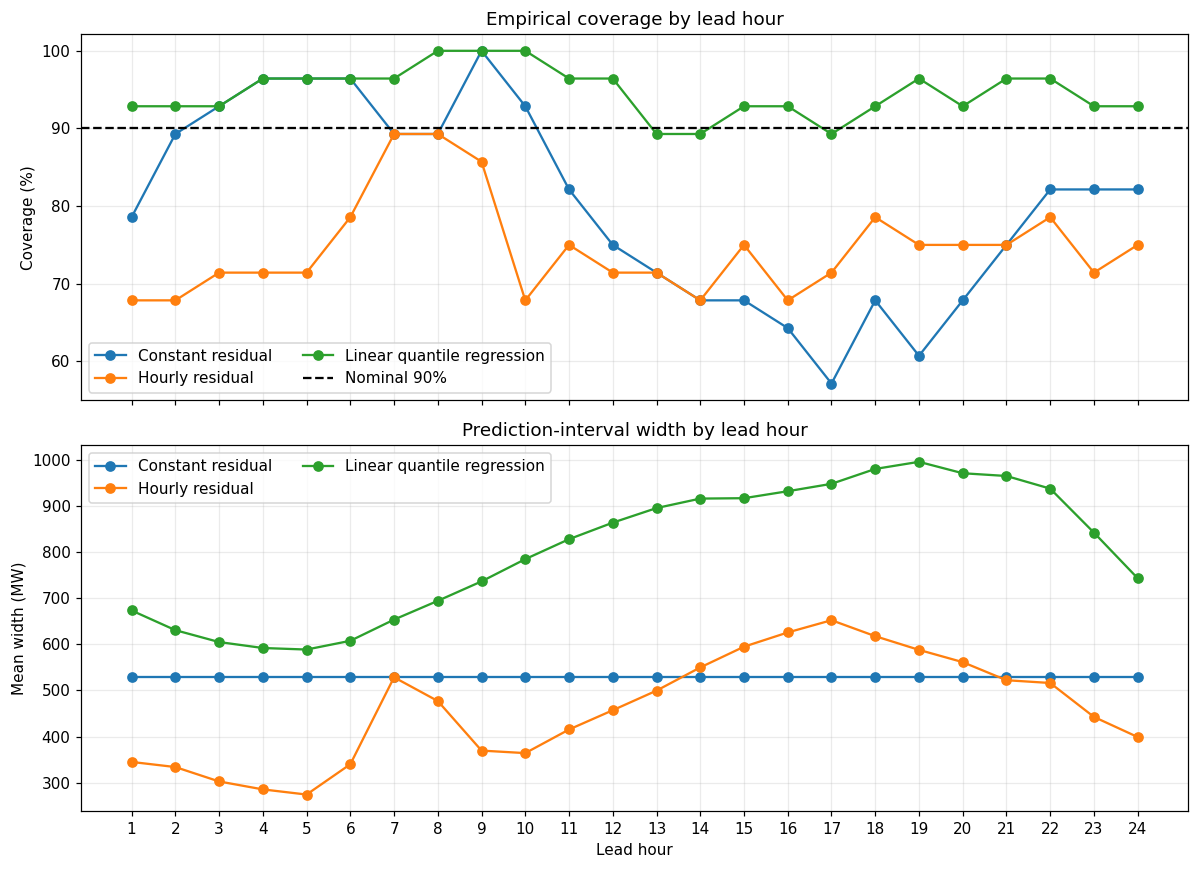

In [10]:
def diagnostics_by_lead(actual, lower, upper):
    diagnostic_frame = pd.DataFrame({
        "actual": actual,
        "lower": lower,
        "upper": upper,
        "lead_hour": actual.index.hour + 1,
    })

    rows = []
    for lead_hour, group in diagnostic_frame.groupby("lead_hour"):
        rows.append({
            "Lead hour": lead_hour,
            "Coverage (%)": empirical_coverage(
                group["actual"], group["lower"], group["upper"]
            ),
            "Mean width (MW)": mean_interval_width(
                group["lower"], group["upper"]
            ),
        })
    return pd.DataFrame(rows).set_index("Lead hour")


lead_diagnostics = {
    method_name: diagnostics_by_lead(test["target"], lower, upper)
    for method_name, (lower, upper) in intervals.items()
}

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for method_name, diagnostic_frame in lead_diagnostics.items():
    axes[0].plot(
        diagnostic_frame.index,
        diagnostic_frame["Coverage (%)"],
        marker="o",
        label=method_name,
    )
    axes[1].plot(
        diagnostic_frame.index,
        diagnostic_frame["Mean width (MW)"],
        marker="o",
        label=method_name,
    )

axes[0].axhline(100 * NOMINAL_COVERAGE, color="black", linestyle="--", label="Nominal 90%")
axes[0].set(title="Empirical coverage by lead hour", ylabel="Coverage (%)")
axes[0].legend(ncol=2)
axes[1].set(title="Prediction-interval width by lead hour", xlabel="Lead hour", ylabel="Mean width (MW)")
axes[1].legend(ncol=2)
axes[1].set_xticks(range(1, 25))
plt.tight_layout()
plt.show()

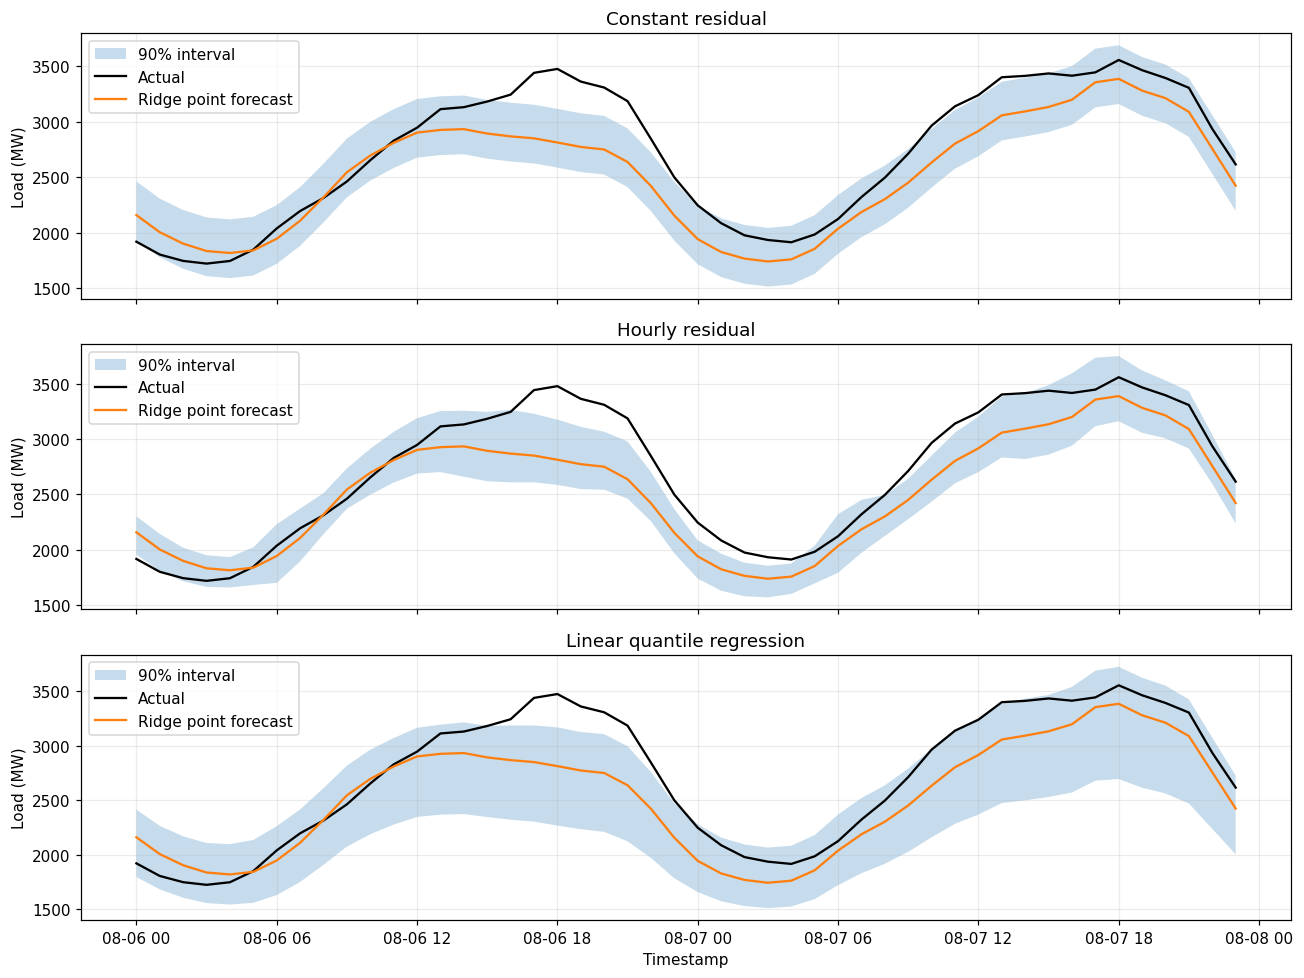

In [11]:
fig, axes = plt.subplots(len(intervals), 1, figsize=(12, 9), sharex=True)

for ax, (method_name, (lower, upper)) in zip(axes, intervals.items()):
    ax.fill_between(
        plot_index,
        lower.loc[plot_index].to_numpy(),
        upper.loc[plot_index].to_numpy(),
        alpha=0.25,
        label="90% interval",
    )
    ax.plot(plot_index, test.loc[plot_index, "target"], color="black", label="Actual")
    ax.plot(plot_index, test_point.loc[plot_index], color="tab:orange", label="Ridge point forecast")
    ax.set(title=method_name, ylabel="Load (MW)")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

## 6. Task 4 — Gaussian temporal scenarios

Prediction intervals describe uncertainty at each hour separately. They do not specify which hourly outcomes may occur together. We now represent each calibration day as one 24-hour residual trajectory.

Two deliberately simple Gaussian approaches are compared:

1. **Independent Gaussian errors:** estimate a mean and standard deviation for each lead hour, then sample every hour independently.
2. **Multivariate Gaussian errors:** estimate a 24-element mean vector and a \(24\times24\) covariance matrix, then sample a complete residual trajectory.

Both methods add sampled residuals to the point forecast. The multivariate model can reproduce correlations between adjacent hours, although a Gaussian distribution remains a strong approximation and the calibration sample contains only 31 daily trajectories.

In [12]:
def independent_gaussian_scenarios(
    point_trajectory, residual_matrix, n_scenarios, random_state
):
    rng = np.random.default_rng(random_state)
    residual_mean = residual_matrix.mean(axis=0)
    residual_std = residual_matrix.std(axis=0, ddof=1)
    sampled_errors = rng.normal(
        loc=residual_mean,
        scale=residual_std,
        size=(n_scenarios, residual_matrix.shape[1]),
    )
    scenarios = point_trajectory[np.newaxis, :] + sampled_errors
    return np.maximum(scenarios, 0)


def multivariate_gaussian_scenarios(
    point_trajectory, residual_matrix, n_scenarios, random_state
):
    rng = np.random.default_rng(random_state)
    residual_mean = residual_matrix.mean(axis=0)
    residual_covariance = np.cov(residual_matrix, rowvar=False)
    sampled_errors = rng.multivariate_normal(
        mean=residual_mean,
        cov=residual_covariance,
        size=n_scenarios,
        method="svd",
    )
    scenarios = point_trajectory[np.newaxis, :] + sampled_errors
    return np.maximum(scenarios, 0)

In [13]:
calibration_residual_matrix = calibration_residuals.to_numpy().reshape(-1, 24)

scenario_day = pd.Timestamp("2007-08-08")
scenario_index = pd.date_range(scenario_day, periods=24, freq="h")
point_trajectory = test_point.loc[scenario_index].to_numpy()
actual_trajectory = test.loc[scenario_index, "target"].to_numpy()

N_SCENARIOS = 500
independent_scenarios = independent_gaussian_scenarios(
    point_trajectory,
    calibration_residual_matrix,
    n_scenarios=N_SCENARIOS,
    random_state=42,
)
multivariate_scenarios = multivariate_gaussian_scenarios(
    point_trajectory,
    calibration_residual_matrix,
    n_scenarios=N_SCENARIOS,
    random_state=42,
)

assert independent_scenarios.shape == (N_SCENARIOS, 24)
assert multivariate_scenarios.shape == (N_SCENARIOS, 24)
assert np.all(independent_scenarios >= 0)
assert np.all(multivariate_scenarios >= 0)

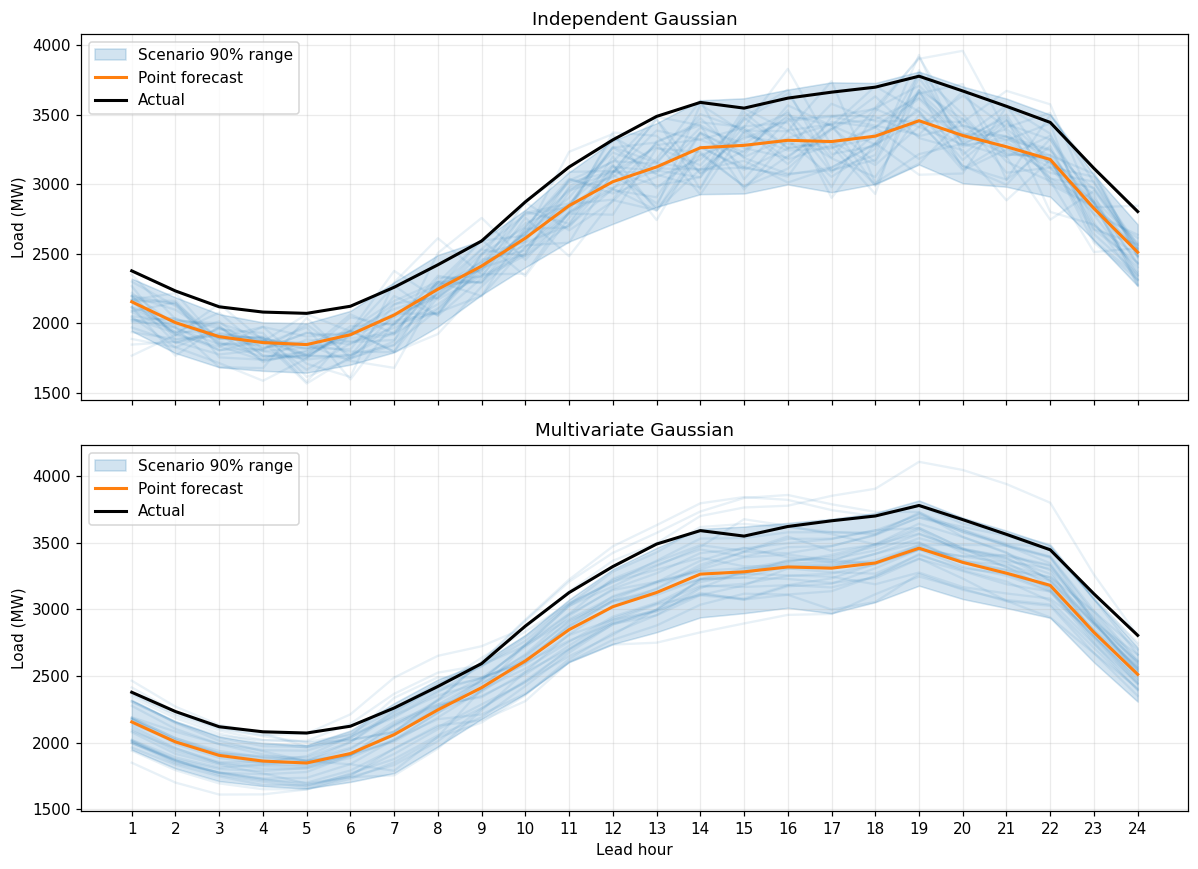

In [14]:
lead_hours = np.arange(1, 25)
scenario_sets = {
    "Independent Gaussian": independent_scenarios,
    "Multivariate Gaussian": multivariate_scenarios,
}

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for ax, (method_name, scenario_values) in zip(axes, scenario_sets.items()):
    for scenario in scenario_values[:30]:
        ax.plot(lead_hours, scenario, color="tab:blue", alpha=0.10)

    lower_scenario = np.quantile(scenario_values, 0.05, axis=0)
    upper_scenario = np.quantile(scenario_values, 0.95, axis=0)
    ax.fill_between(
        lead_hours,
        lower_scenario,
        upper_scenario,
        color="tab:blue",
        alpha=0.20,
        label="Scenario 90% range",
    )
    ax.plot(lead_hours, point_trajectory, color="tab:orange", linewidth=2, label="Point forecast")
    ax.plot(lead_hours, actual_trajectory, color="black", linewidth=2, label="Actual")
    ax.set(title=method_name, ylabel="Load (MW)")
    ax.legend(loc="upper left")

axes[-1].set(xlabel="Lead hour", xticks=lead_hours)
plt.tight_layout()
plt.show()

In [15]:
def mean_adjacent_hour_correlation(residual_trajectories):
    correlation_matrix = np.corrcoef(residual_trajectories, rowvar=False)
    return np.mean(np.diag(correlation_matrix, k=1))


scenario_dependence = pd.Series({
    "Calibration residuals": mean_adjacent_hour_correlation(
        calibration_residual_matrix
    ),
    "Independent Gaussian": mean_adjacent_hour_correlation(
        independent_scenarios - point_trajectory
    ),
    "Multivariate Gaussian": mean_adjacent_hour_correlation(
        multivariate_scenarios - point_trajectory
    ),
}, name="Mean adjacent-hour residual correlation")

scenario_dependence.to_frame().round(2)

,Mean adjacent-hour residual correlation
Calibration residuals,0.96
Independent Gaussian,0.02
Multivariate Gaussian,0.96


## 7. PV forecasting section — implementation pending data

This section deliberately stops at the design stage. We still need to confirm the PV dataset, timezone, site location, installed capacity, units, sampling convention and available weather forecasts. Inventing these fields would make the forecast specification unreliable.

### 7.1 Planned point-forecast workflow

Once the data are available, the exercise will ask students to:

1. inspect missing timestamps, explicit missing values and daylight patterns;
2. define a chronological training, calibration and test split;
3. create origin-valid day-ahead predictors from forecast weather, solar position and historical PV generation;
4. fit a simple point model, initially using one linear model per hour of day as in Tutorial 7; and
5. report full-day and daylight-only MAE or RMSE, preferably normalised by installed capacity.

MAPE will not be used because PV output is zero at night and may be close to zero near sunrise and sunset.

### 7.2 Physical constraints

Raw regression output will be post-processed in this order:

\[
\hat{p}^{(1)}_t = \max(0,\hat{p}_t),
\qquad
\hat{p}^{(2)}_t =
\begin{cases}
\hat{p}^{(1)}_t, & \text{during daylight},\\
0, & \text{at night}.
\end{cases}
\]

If installed capacity or another valid upper bound is available, the forecast will also be capped at that limit. The daylight mask should come from site location and solar position, or another justified physical indicator. A fixed rule such as “06:00–18:00” would be inappropriate across seasons and locations.

### 7.3 Planned probabilistic extension

The same three interval methods and two Gaussian scenario methods will later be transferred to PV. Their physical post-processing will require particular care:

- night-time point forecasts, quantiles, interval bounds and scenarios should all equal zero;
- lower bounds and scenarios cannot be negative;
- upper bounds should respect installed or available PV power where that information exists; and
- uncertainty should vary through the day. A constant-width interval would usually be implausible because night-time uncertainty collapses to zero while daylight uncertainty depends on solar and cloud conditions.

In [16]:
# PV implementation placeholder
#
# PV_DATA_PATH = Path("data") / "tutorial_08" / "pv_data.csv"
#
# TODO after the dataset is confirmed:
# 1. load and validate the timestamp, timezone, units and capacity metadata;
# 2. construct origin-valid point-forecast features;
# 3. create a solar-position-based daylight mask;
# 4. project negative forecasts to zero and force night-time forecasts to zero;
# 5. transfer the residual, quantile and scenario methods from the load example.

## 8. Interpretation questions

1. **How do the constant and hour-dependent residual intervals differ in coverage and width?**  
   The constant interval covers 80.21% of test observations with a mean width of 529.52 MW. The hourly interval is sharper at 460.98 MW, but its coverage falls to 74.55%, so the extra flexibility does not correct the July-to-August calibration shift in this example.

2. **Which of the three interval methods has the best interval score on the test period?**  
   Linear quantile regression has the lowest interval score at 908.38. Its 94.64% coverage exceeds the nominal 90% and its mean width is 804.67 MW, illustrating that the interval score balances sharpness with penalties for misses rather than rewarding coverage alone.

3. **Why must residual quantiles come from calibration data rather than test residuals?**  
   Test residuals contain the outcomes used for final evaluation. Using them to construct the intervals would leak test information and make coverage look too favourable.

4. **What does the coverage-by-lead plot reveal that overall coverage hides?**  
   Overall coverage can average together hours with undercoverage and hours with overcoverage. The lead plot identifies specific parts of the day where intervals are too narrow, too wide or systematically biased.

5. **Why do independently sampled Gaussian scenarios look less coherent than multivariate Gaussian scenarios?**  
   Independent sampling allows the error to jump without regard to neighbouring hours. Its mean adjacent-hour residual correlation is about 0.02, whereas the multivariate scenarios reproduce the calibration value of about 0.96 and therefore create more persistent deviations.

6. **What limitation follows from estimating a 24-dimensional covariance matrix from only 31 calibration days?**  
   The estimate is noisy and sensitive to unusual days. A longer calibration period, covariance regularisation or a lower-dimensional dependence model would provide a more stable estimate.

7. **Why must PV forecasts equal zero at night rather than merely being projected to non-negative values?**  
   Non-negative projection could leave a small positive forecast at night. With no solar input, physically valid PV generation is exactly zero, so the daylight mask must impose that stronger constraint.

8. **Why should PV prediction intervals normally change width through the day?**  
   Night-time uncertainty collapses to zero. During daylight, uncertainty changes with available solar power, cloud variability and the forecast horizon, so one constant interval width would misrepresent the process.

9. **Why is MAPE unsuitable for a complete PV time series?**  
   The denominator is zero at night and can be very small around sunrise or sunset. This makes the metric undefined or dominated by low-output hours.

## References

- Gneiting, T. and Katzfuss, M. (2014) ‘Probabilistic forecasting’, *Annual Review of Statistics and Its Application*, 1, pp. 125–151.
- Hong, T. and Fan, S. (2016) ‘Probabilistic electric load forecasting: A tutorial review’, *International Journal of Forecasting*, 32(3), pp. 914–938.
- Hong, T., Pinson, P. and Fan, S. (2014) ‘Global Energy Forecasting Competition 2012’, *International Journal of Forecasting*, 30(2), pp. 357–363. https://doi.org/10.1016/j.ijforecast.2013.07.001
- Koenker, R. and Bassett, G. (1978) ‘Regression quantiles’, *Econometrica*, 46(1), pp. 33–50.
- Van der Meer, D.W., Widén, J. and Munkhammar, J. (2018) ‘Review on probabilistic forecasting of photovoltaic power production and electricity consumption’, *Renewable and Sustainable Energy Reviews*, 81, pp. 1484–1512.